## 1. Import Libraries and Setup

In [1]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as patches

# Machine Learning libraries
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
from sklearn.metrics import precision_score, recall_score, f1_score

# XGBoost library
try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
    print("✅ XGBoost available for gradient boosting")
except ImportError:
    XGBOOST_AVAILABLE = False
    print("❌ XGBoost not available - install with: pip install xgboost")
    raise ImportError("XGBoost is required for this analysis")

# Suppress warnings for clean output
import warnings
warnings.filterwarnings('ignore')

# Set plotting parameters
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("🚀 All libraries imported successfully!")
print("📊 Ready to start DeepSeek XGBoost Analysis")
print("🔬 Gradient boosting for high-performance prediction!")

✅ XGBoost available for gradient boosting
🚀 All libraries imported successfully!
📊 Ready to start DeepSeek XGBoost Analysis
🔬 Gradient boosting for high-performance prediction!


## 2. Load and Explore Dataset

In [2]:
# Load the dataset - Update this path to match your file location
df = pd.read_csv('DeepSeek by Engineering Students_SEM & ML-Final (Responses) - Form Responses 1.csv')

# Clean column names (fix trailing spaces)
df.columns = df.columns.str.strip()

# Display basic information
print(f"📊 Dataset Shape: {df.shape}")
print(f"📋 Total Responses: {len(df)}")
print(f"📈 Total Columns: {len(df.columns)}")

# Display first few rows
print("\n📖 First 5 rows:")
display(df.head())

📊 Dataset Shape: (247, 30)
📋 Total Responses: 247
📈 Total Columns: 30

📖 First 5 rows:


,Timestamp,Email Address (force verified),Email Address,Gender,What is your age?,What is your current academic level?,"What is your field of engineering study? \n(Ex: Cse, Swe)",Have you used DeepSeek before?,Experience with AI tools?,1. DeepSeek helps me solve complex engineering problems more effectively. (DeepSeek আমাকে জটিল প্রকৌশল সমস্যা আরও কার্যকরভাবে সমাধান করতে সাহায্য করে),...,12. There is adequate training or documentation available for DeepSeek. (DeepSeek-এর জন্য পর্যাপ্ত প্রশিক্ষণ বা ডকুমেন্টেশন উপলব্ধ আছে),13. I believe the solutions provided by DeepSeek are reliable. (আমি বিশ্বাস করি DeepSeek দ্বারা প্রদত্ত সমাধানগুলি নির্ভরযোগ্য),14. DeepSeek produces consistent and accurate results. (DeepSeek ধারাবাহিক এবং সঠিক ফলাফল প্রদান করে),15. I trust DeepSeek to handle my academic data safely. (আমি আমার একাডেমিক ডেটা নিরাপদে পরিচালনার জন্য DeepSeek-কে বিশ্বাস করি),16. I worry DeepSeek might share my personal data without consent. (আমি চিন্তা করি DeepSeek আমার ব্যক্তিগত তথ্য অনুমতি ছাড়া শেয়ার করতে পারে),17. I am concerned that errors in DeepSeek’s solutions could negatively affect my work. (আমি উদ্বিগ্ন যে DeepSeek-এর সমাধানে ত্রুটি আমার কাজকে নেতিবাচকভাবে প্রভাবিত করতে পারে),18. I feel uncertain about the privacy of my inputs when using DeepSeek. (DeepSeek ব্যবহার করার সময় আমার ইনপুটের গোপনীয়তা নিয়ে আমি অনিশ্চিত বোধ করি),19. I intend to use DeepSeek regularly in the next semester. (আমি আগামী সেমিস্টারে নিয়মিতভাবে DeepSeek ব্যবহার করার পরিকল্পনা করছি),20. I will recommend DeepSeek to my classmates. (আমি আমার সহপাঠীদের DeepSeek ব্যবহার করার পরামর্শ দেব),21. I am willing to invest time learning more about DeepSeek features. (আমি DeepSeek-এর ফিচারগুলো সম্পর্কে আরও জানতে সময় বিনিয়োগ করতে ইচ্ছুক)
0,8/2/2025 15:38:58,islam15-5708@diu.edu.bd,NaN,Male,24 to 26,Fourth Year,CSE,Yes,High,Strongly Agree,...,Strongly Agree,Agree,Agree,Strongly Agree,Neutral,Disagree,Neutral,Agree,Agree,Disagree
1,8/2/2025 15:52:43,farhadur15-4800@diu.edu.bd,NaN,Male,24 to 26,Fourth Year,Cse,Yes,Medium,Agree,...,Neutral,Agree,Agree,Agree,Agree,Agree,Neutral,Neutral,Neutral,Neutral
2,8/2/2025 15:57:16,anikanikseo@gmail.com,NaN,Male,24 to 26,Fourth Year,CSE,Yes,Medium,Agree,...,Neutral,Agree,Agree,Neutral,Neutral,Disagree,Neutral,Agree,Agree,Agree
3,8/2/2025 16:27:07,hossain15-5963@diu.edu.bd,NaN,Male,24 to 26,Fourth Year,CSE,Yes,Medium,Agree,...,Disagree,Neutral,Neutral,Disagree,Disagree,Agree,Neutral,Disagree,Neutral,Agree
4,8/2/2025 22:57:14,khan15-5728@diu.edu.bd,NaN,Male,21 to 23,Fourth Year,Cse,Yes,High,Neutral,...,Disagree,Neutral,Neutral,Disagree,Disagree,Disagree,Neutral,Disagree,Neutral,Agree


In [3]:
# Examine column structure
print("📝 All Column Names:")
for i, col in enumerate(df.columns):
    print(f"{i+1:2d}. '{col}'")

📝 All Column Names:
 1. 'Timestamp'
 2. 'Email Address (force verified)'
 3. 'Email Address'
 4. 'Gender'
 5. 'What is your age?'
 6. 'What is your current academic level?'
 7. 'What is your field of engineering study? 
(Ex: Cse, Swe)'
 8. 'Have you used DeepSeek before?'
 9. 'Experience with AI tools?'
10. '1. DeepSeek helps me solve complex engineering problems more effectively. (DeepSeek আমাকে জটিল প্রকৌশল সমস্যা আরও কার্যকরভাবে সমাধান করতে সাহায্য করে)'
11. '2. Using DeepSeek improves my academic performance (e.g. grades). (DeepSeek ব্যবহার করার ফলে আমার একাডেমিক পারফরম্যান্স (যেমন: গ্রেড) উন্নত হয়)'
12. '3. DeepSeek provides valuable insights that I couldn’t easily get otherwise. (DeepSeek আমাকে এমন মূল্যবান অন্তর্দৃষ্টি প্রদান করে, যা অন্যভাবে সহজে পাওয়া সম্ভব নয়)'
13. '4. Learning to use DeepSeek is easy for me. (DeepSeek ব্যবহার করতে শেখা আমার জন্য সহজ)'
14. '5. DeepSeek’s interface is intuitive. (DeepSeek-এর ইন্টারফেসটি সহজবোধ্য)'
15. '6. It is effortless to get DeepSeek to

## 3. Data Preprocessing and Column Mapping

In [4]:
# Find demographic columns dynamically
demographic_cols_found = []
for col in df.columns:
    if any(keyword in col.lower() for keyword in ['gender', 'age', 'academic', 'field', 'deepseek', 'ai tools', 'experience']):
        demographic_cols_found.append(col)

print(f"🔍 Demographic columns found: {len(demographic_cols_found)}")
for col in demographic_cols_found:
    print(f"  - '{col}'")

# Find Likert scale questions (questions with numbers)
likert_questions = []
for col in df.columns:
    if any(str(i) + '.' in col for i in range(1, 22)):
        likert_questions.append(col)

print(f"\n📊 Likert Scale Questions Found: {len(likert_questions)}")
for i, col in enumerate(likert_questions[:5]):  # Show first 5
    print(f"{i+1:2d}. {col[:80]}...")

🔍 Demographic columns found: 27
  - 'Gender'
  - 'What is your age?'
  - 'What is your current academic level?'
  - 'What is your field of engineering study? 
(Ex: Cse, Swe)'
  - 'Have you used DeepSeek before?'
  - 'Experience with AI tools?'
  - '1. DeepSeek helps me solve complex engineering problems more effectively. (DeepSeek আমাকে জটিল প্রকৌশল সমস্যা আরও কার্যকরভাবে সমাধান করতে সাহায্য করে)'
  - '2. Using DeepSeek improves my academic performance (e.g. grades). (DeepSeek ব্যবহার করার ফলে আমার একাডেমিক পারফরম্যান্স (যেমন: গ্রেড) উন্নত হয়)'
  - '3. DeepSeek provides valuable insights that I couldn’t easily get otherwise. (DeepSeek আমাকে এমন মূল্যবান অন্তর্দৃষ্টি প্রদান করে, যা অন্যভাবে সহজে পাওয়া সম্ভব নয়)'
  - '4. Learning to use DeepSeek is easy for me. (DeepSeek ব্যবহার করতে শেখা আমার জন্য সহজ)'
  - '5. DeepSeek’s interface is intuitive. (DeepSeek-এর ইন্টারফেসটি সহজবোধ্য)'
  - '6. It is effortless to get DeepSeek to perform the tasks I need. (আমার প্রয়োজনীয় কাজগুলো করাতে De

In [5]:
# Create demographic column mappings - Initialize empty dictionary first
actual_demographic_mapping = {}

for col in df.columns:
    if col == 'Gender':
        actual_demographic_mapping['Gender'] = 'Gender'
    elif 'age' in col.lower():
        actual_demographic_mapping[col] = 'Age'
    elif 'academic level' in col.lower():
        actual_demographic_mapping[col] = 'Academic_Level'
    elif 'field of engineering study' in col.lower():
        actual_demographic_mapping[col] = 'Field_Study'
    elif 'deepseek before' in col.lower():
        actual_demographic_mapping[col] = 'Used_DeepSeek_Before'
    elif 'ai tools' in col.lower():
        actual_demographic_mapping[col] = 'AI_Experience'

print("🔄 Demographic column mappings:")
for original, new in actual_demographic_mapping.items():
    print(f"  '{original}' → '{new}'")

print(f"\n✅ Found {len(actual_demographic_mapping)} demographic mappings")

🔄 Demographic column mappings:
  'Gender' → 'Gender'
  'What is your age?' → 'Age'
  'What is your current academic level?' → 'Academic_Level'
  'What is your field of engineering study? 
(Ex: Cse, Swe)' → 'Field_Study'
  'Have you used DeepSeek before?' → 'Used_DeepSeek_Before'
  'Experience with AI tools?' → 'AI_Experience'
  '7.  My classmates encourage me to use DeepSeek.(আমার সহপাঠীরা আমাকে DeepSeek ব্যবহার করতে উৎসাহিত করে)' → 'Age'

✅ Found 7 demographic mappings


In [6]:
# Create UTAUT construct mappings
construct_mapping = {}

if len(likert_questions) >= 21:
    construct_mapping = {
        # Performance Expectancy (PE) - Items 1, 2, 3
        likert_questions[0]: 'PE1',  # DeepSeek helps solve problems
        likert_questions[1]: 'PE2',  # Improves academic performance
        likert_questions[2]: 'PE3',  # Provides valuable insights

        # Effort Expectancy (EE) - Items 4, 5, 6
        likert_questions[3]: 'EE1',  # Easy to learn
        likert_questions[4]: 'EE2',  # Intuitive interface
        likert_questions[5]: 'EE3',  # Effortless to use

        # Social Influence (SI) - Items 7, 8, 9
        likert_questions[6]: 'SI1',  # Classmates encourage
        likert_questions[7]: 'SI2',  # Instructors recommend
        likert_questions[8]: 'SI3',  # Influential people think should adopt

        # Facilitating Conditions (FC) - Items 10, 11, 12
        likert_questions[9]: 'FC1',   # Necessary resources
        likert_questions[10]: 'FC2',  # IT support available
        likert_questions[11]: 'FC3',  # Training/documentation available

        # Trust (TR) - Items 13, 14, 15
        likert_questions[12]: 'TR1',  # Solutions are reliable
        likert_questions[13]: 'TR2',  # Consistent and accurate
        likert_questions[14]: 'TR3',  # Trust with academic data

        # Perceived Risk (PR) - Items 16, 17, 18
        likert_questions[15]: 'PR1',  # Worry about data sharing
        likert_questions[16]: 'PR2',  # Concerned about errors
        likert_questions[17]: 'PR3',  # Uncertain about privacy

        # Behavioral Intention (BI) - Items 19, 20, 21
        likert_questions[18]: 'BI1',  # Intend to use regularly
        likert_questions[19]: 'BI2',  # Will recommend
        likert_questions[20]: 'BI3'   # Willing to invest time learning
    }

    print(f"✅ UTAUT construct mappings created: {len(construct_mapping)}")
    print("📋 Construct breakdown:")
    print("  - Performance Expectancy (PE): 3 items")
    print("  - Effort Expectancy (EE): 3 items")
    print("  - Social Influence (SI): 3 items")
    print("  - Facilitating Conditions (FC): 3 items")
    print("  - Trust (TR): 3 items")
    print("  - Perceived Risk (PR): 3 items")
    print("  - Behavioral Intention (BI): 3 items")
else:
    print(f"⚠️ WARNING: Expected 21 Likert questions, found {len(likert_questions)}")
    print("Some constructs may be incomplete.")

print(f"\n📊 Construct mapping summary: {len(construct_mapping)} items mapped")

✅ UTAUT construct mappings created: 21
📋 Construct breakdown:
  - Performance Expectancy (PE): 3 items
  - Effort Expectancy (EE): 3 items
  - Social Influence (SI): 3 items
  - Facilitating Conditions (FC): 3 items
  - Trust (TR): 3 items
  - Perceived Risk (PR): 3 items
  - Behavioral Intention (BI): 3 items

📊 Construct mapping summary: 21 items mapped


In [7]:
# Apply all mappings to create clean dataset
all_mappings = {**actual_demographic_mapping, **construct_mapping}
df_clean = df.rename(columns=all_mappings)

print(f"🔄 Applied {len(all_mappings)} column mappings successfully!")
print(f"📊 Cleaned dataset shape: {df_clean.shape}")

# Show sample of cleaned column names
print(f"\n📋 Sample of cleaned column names:")
sample_cols = [col for col in df_clean.columns if col in ['Gender', 'Age', 'PE1', 'PE2', 'SI1', 'TR1', 'BI1']]
for col in sample_cols:
    print(f"  ✅ {col}")

print(f"\n🎯 Ready for XGBoost data analysis!")

🔄 Applied 27 column mappings successfully!
📊 Cleaned dataset shape: (247, 30)

📋 Sample of cleaned column names:
  ✅ Gender
  ✅ Age
  ✅ PE1
  ✅ PE2
  ✅ SI1
  ✅ TR1
  ✅ BI1

🎯 Ready for XGBoost data analysis!


## 4. Convert Likert Scale to Numeric Values

In [8]:
# Define Likert scale mapping
likert_mapping = {
    'Strongly Disagree': 1,
    'Disagree': 2,
    'Neutral': 3,
    'Agree': 4,
    'Strongly Agree': 5
}

# Identify existing Likert columns
likert_cols = ['PE1', 'PE2', 'PE3', 'EE1', 'EE2', 'EE3', 'SI1', 'SI2', 'SI3',
               'FC1', 'FC2', 'FC3', 'TR1', 'TR2', 'TR3', 'PR1', 'PR2', 'PR3',
               'BI1', 'BI2', 'BI3']

existing_likert_cols = [col for col in likert_cols if col in df_clean.columns]

print(f"🔢 LIKERT SCALE CONVERSION")
print(f"📊 Found {len(existing_likert_cols)} Likert columns")
print(f"📋 Columns: {existing_likert_cols}")
print(f"🔄 Mapping: {likert_mapping}")

🔢 LIKERT SCALE CONVERSION
📊 Found 21 Likert columns
📋 Columns: ['PE1', 'PE2', 'PE3', 'EE1', 'EE2', 'EE3', 'SI1', 'SI2', 'SI3', 'FC1', 'FC2', 'FC3', 'TR1', 'TR2', 'TR3', 'PR1', 'PR2', 'PR3', 'BI1', 'BI2', 'BI3']
🔄 Mapping: {'Strongly Disagree': 1, 'Disagree': 2, 'Neutral': 3, 'Agree': 4, 'Strongly Agree': 5}


In [9]:
# Convert Likert responses to numeric
conversion_successful = 0
conversion_failed = 0

print(f"🔄 Converting Likert scale responses...")

for col in existing_likert_cols:
    # Check unique values before conversion
    unique_before = df_clean[col].unique()
    print(f"\n🔄 Converting {col}...")
    print(f"  Original values: {len(unique_before)} unique values")

    # Apply mapping
    df_clean[col] = df_clean[col].map(likert_mapping)

    # Check conversion success
    null_count = df_clean[col].isnull().sum()
    if null_count > 0:
        print(f"  ⚠️ {null_count} unmapped values")
        conversion_failed += 1
    else:
        print(f"  ✅ Success - Range: {df_clean[col].min():.0f} to {df_clean[col].max():.0f}")
        conversion_successful += 1

print(f"\n📈 Conversion Summary: {conversion_successful} successful, {conversion_failed} failed")
print(f"✅ Likert scale conversion completed!")

🔄 Converting Likert scale responses...

🔄 Converting PE1...
  Original values: 5 unique values
  ✅ Success - Range: 1 to 5

🔄 Converting PE2...
  Original values: 5 unique values
  ✅ Success - Range: 1 to 5

🔄 Converting PE3...
  Original values: 5 unique values
  ✅ Success - Range: 1 to 5

🔄 Converting EE1...
  Original values: 5 unique values
  ✅ Success - Range: 1 to 5

🔄 Converting EE2...
  Original values: 5 unique values
  ✅ Success - Range: 1 to 5

🔄 Converting EE3...
  Original values: 5 unique values
  ✅ Success - Range: 1 to 5

🔄 Converting SI1...
  Original values: 5 unique values
  ✅ Success - Range: 1 to 5

🔄 Converting SI2...
  Original values: 5 unique values
  ✅ Success - Range: 1 to 5

🔄 Converting SI3...
  Original values: 5 unique values
  ✅ Success - Range: 1 to 5

🔄 Converting FC1...
  Original values: 5 unique values
  ✅ Success - Range: 1 to 5

🔄 Converting FC2...
  Original values: 5 unique values
  ✅ Success - Range: 1 to 5

🔄 Converting FC3...
  Original value

## 5. Create Target Variable (High_BI)

In [10]:
# Check availability of BI columns
bi_cols = ['BI1', 'BI2', 'BI3']
available_bi_cols = [col for col in bi_cols if col in df_clean.columns]

print(f"🎯 TARGET VARIABLE CREATION")
print(f"📊 Available BI columns: {available_bi_cols}")

if len(available_bi_cols) == 3:
    # Calculate average BI score
    df_clean['BI_avg'] = (df_clean['BI1'] + df_clean['BI2'] + df_clean['BI3']) / 3

    # Create High_BI target variable (High_BI = 1 if BI_avg >= 4, else 0)
    df_clean['High_BI'] = (df_clean['BI_avg'] >= 4).astype(int)

    print(f"🎯 Target Variable Results:")
    print(f"📊 BI Average Range: {df_clean['BI_avg'].min():.2f} - {df_clean['BI_avg'].max():.2f}")
    print(f"📊 BI Average Mean: {df_clean['BI_avg'].mean():.2f} ± {df_clean['BI_avg'].std():.2f}")

    high_bi_count = (df_clean['BI_avg'] >= 4).sum()
    low_bi_count = (df_clean['BI_avg'] < 4).sum()

    print(f"\n🎯 High_BI Distribution:")
    print(f"  High Intention (BI ≥ 4): {high_bi_count} students ({high_bi_count/len(df_clean)*100:.1f}%)")
    print(f"  Low Intention (BI < 4): {low_bi_count} students ({low_bi_count/len(df_clean)*100:.1f}%)")

    print(f"\n✅ Target variable 'High_BI' created successfully!")
else:
    print("❌ Cannot create target variable without complete BI data")
    raise ValueError("Missing BI columns - cannot proceed")

🎯 TARGET VARIABLE CREATION
📊 Available BI columns: ['BI1', 'BI2', 'BI3']
🎯 Target Variable Results:
📊 BI Average Range: 1.00 - 5.00
📊 BI Average Mean: 3.31 ± 0.81

🎯 High_BI Distribution:
  High Intention (BI ≥ 4): 76 students (30.8%)
  Low Intention (BI < 4): 171 students (69.2%)

✅ Target variable 'High_BI' created successfully!


## 6. Prepare Features for XGBoost

In [11]:
# Select features (exclude BI items from predictors)
available_likert_features = [col for col in existing_likert_cols if col not in ['BI1', 'BI2', 'BI3']]

# Select demographic features that exist
potential_demographic_features = ['Gender', 'Age', 'Academic_Level', 'Field_Study', 'AI_Experience', 'Used_DeepSeek_Before']
demographic_features = [col for col in potential_demographic_features if col in df_clean.columns]

print(f"🔧 FEATURE PREPARATION FOR XGBOOST")
print(f"📊 Available Likert features ({len(available_likert_features)}):")
for i, feature in enumerate(available_likert_features):
    print(f"  {i+1:2d}. {feature}")

print(f"\n👥 Available demographic features ({len(demographic_features)}):")
for i, feature in enumerate(demographic_features):
    print(f"  {i+1}. {feature}")

🔧 FEATURE PREPARATION FOR XGBOOST
📊 Available Likert features (18):
   1. PE1
   2. PE2
   3. PE3
   4. EE1
   5. EE2
   6. EE3
   7. SI1
   8. SI2
   9. SI3
  10. FC1
  11. FC2
  12. FC3
  13. TR1
  14. TR2
  15. TR3
  16. PR1
  17. PR2
  18. PR3

👥 Available demographic features (6):
  1. Gender
  2. Age
  3. Academic_Level
  4. Field_Study
  5. AI_Experience
  6. Used_DeepSeek_Before


In [12]:
# Clean Field_Study if it exists
if 'Field_Study' in df_clean.columns:
    print(f"🧹 Cleaning Field_Study column...")

    # Standardize case
    df_clean['Field_Study'] = df_clean['Field_Study'].str.upper().str.strip()

    print(f"\n📊 Original Field_Study distribution:")
    original_dist = df_clean['Field_Study'].value_counts()
    for value, count in original_dist.head(10).items():  # Show top 10
        print(f"  {value}: {count}")
    if len(original_dist) > 10:
        print(f"  ... and {len(original_dist)-10} more values")

    # Group similar fields
    field_mapping = {
        'CSE': 'CSE', 'CSE ': 'CSE', 'COMPUTER': 'CSE', 'MCT': 'CSE',
        'SWE': 'SWE', 'SWE ': 'SWE',
        'EEE': 'EEE',
        'CE': 'CE', 'CIVIL': 'CE',
        'CIS': 'CIS', 'TE': 'TE', 'ICE': 'ICE', 'NFE': 'NFE',
        'PHARMACY': 'PHARMACY', 'BBA': 'BBA'
    }

    df_clean['Field_Study_Clean'] = df_clean['Field_Study'].map(field_mapping).fillna('OTHER')

    print(f"\n🔄 Cleaned Field_Study distribution:")
    cleaned_dist = df_clean['Field_Study_Clean'].value_counts()
    for value, count in cleaned_dist.items():
        print(f"  {value}: {count} ({count/len(df_clean)*100:.1f}%)")

    # Update demographic features list
    if 'Field_Study' in demographic_features:
        demographic_features.remove('Field_Study')
        demographic_features.append('Field_Study_Clean')

    print(f"✅ Field_Study cleaned and mapped")
else:
    print(f"ℹ️ Field_Study column not found - skipping cleaning")

print(f"\n✅ Final demographic features: {demographic_features}")

🧹 Cleaning Field_Study column...

📊 Original Field_Study distribution:
  CSE: 168
  SWE: 29
  EEE: 14
  CE: 6
  PHARMACY: 5
  CIS: 4
  BBA: 4
  NFE: 3
  TE: 3
  CIVIL: 1
  ... and 10 more values

🔄 Cleaned Field_Study distribution:
  CSE: 170 (68.8%)
  SWE: 29 (11.7%)
  EEE: 14 (5.7%)
  OTHER: 7 (2.8%)
  CE: 7 (2.8%)
  PHARMACY: 5 (2.0%)
  CIS: 4 (1.6%)
  BBA: 4 (1.6%)
  NFE: 3 (1.2%)
  TE: 3 (1.2%)
  ICE: 1 (0.4%)
✅ Field_Study cleaned and mapped

✅ Final demographic features: ['Gender', 'Age', 'Academic_Level', 'AI_Experience', 'Used_DeepSeek_Before', 'Field_Study_Clean']


## 7. Encode Categorical Variables (XGBoost handles non-scaled data)

In [13]:
# Create copy for ML processing
df_ml = df_clean.copy()

# Label encode categorical variables (XGBoost can handle categorical data directly)
label_encoders = {}

print(f"🔢 CATEGORICAL VARIABLE ENCODING FOR XGBOOST")
print(f"="*50)

for col in demographic_features:
    if col in df_ml.columns:
        le = LabelEncoder()
        df_ml[col + '_encoded'] = le.fit_transform(df_ml[col].astype(str))
        label_encoders[col] = le

        print(f"\n🔄 {col} encoding:")
        encoding_map = dict(zip(le.classes_, le.transform(le.classes_)))
        for original, encoded in list(encoding_map.items())[:5]:  # Show first 5
            print(f"  '{original}' → {encoded}")
        if len(encoding_map) > 5:
            print(f"  ... and {len(encoding_map)-5} more values")
        print(f"  ✅ {len(encoding_map)} categories encoded")

# Create feature matrix and target vector
X_features = available_likert_features + [col + '_encoded' for col in demographic_features]
X = df_ml[X_features].copy()
y = df_ml['High_BI'].copy()

print(f"\n📊 FEATURE MATRIX SUMMARY FOR XGBOOST")
print(f"📈 Total features: {len(X_features)}")
print(f"📊 Likert features: {len(available_likert_features)}")
print(f"👥 Demographic features: {len(demographic_features)}")
print(f"🎯 Target variable: High_BI (Binary: 0/1)")
print(f"📏 Data shapes: X={X.shape}, y={y.shape}")

# Note: XGBoost handles raw features well, no scaling required
print(f"\nℹ️ XGBoost Note: No feature scaling required - tree-based methods handle mixed scales well")

🔢 CATEGORICAL VARIABLE ENCODING FOR XGBOOST

🔄 Gender encoding:
  'Female' → 0
  'Male' → 1
  ✅ 2 categories encoded

🔄 Age encoding:
  '18 to 20' → 0
  '21 to 23' → 1
  '24 to 26' → 2
  '27 to 29' → 3
  ✅ 4 categories encoded

🔄 Academic_Level encoding:
  'First Year' → 0
  'Fourth Year' → 1
  'Postgraduate (Master's/PhD)' → 2
  'Second Year' → 3
  'Third Year' → 4
  ✅ 5 categories encoded

🔄 AI_Experience encoding:
  'High' → 0
  'Low' → 1
  'Medium' → 2
  ✅ 3 categories encoded

🔄 Used_DeepSeek_Before encoding:
  'No' → 0
  'Yes' → 1
  ✅ 2 categories encoded

🔄 Field_Study_Clean encoding:
  'BBA' → 0
  'CE' → 1
  'CIS' → 2
  'CSE' → 3
  'EEE' → 4
  ... and 6 more values
  ✅ 11 categories encoded

📊 FEATURE MATRIX SUMMARY FOR XGBOOST
📈 Total features: 24
📊 Likert features: 18
👥 Demographic features: 6
🎯 Target variable: High_BI (Binary: 0/1)
📏 Data shapes: X=(247, 24), y=(247,)

ℹ️ XGBoost Note: No feature scaling required - tree-based methods handle mixed scales well


## 8. Data Splitting and Preparation

In [14]:
# Split data for XGBoost
print(f"🔀 DATA SPLITTING FOR XGBOOST TRAINING")
print(f"="*40)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"🔀 Data split: Train={X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.0f}%), Test={X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.0f}%)")

# Show class distribution in splits
train_dist = y_train.value_counts().sort_index()
test_dist = y_test.value_counts().sort_index()

print(f"\n🎯 Training set High_BI distribution:")
for value, count in train_dist.items():
    print(f"  {value}: {count} ({count/len(y_train)*100:.1f}%)")

print(f"\n🎯 Test set High_BI distribution:")
for value, count in test_dist.items():
    print(f"  {value}: {count} ({count/len(y_test)*100:.1f}%)")

print(f"\n✅ Data ready for XGBoost training!")
print(f"📊 Feature names available for importance analysis: {len(X_features)} features")

🔀 DATA SPLITTING FOR XGBOOST TRAINING
🔀 Data split: Train=197 (80%), Test=50 (20%)

🎯 Training set High_BI distribution:
  0: 136 (69.0%)
  1: 61 (31.0%)

🎯 Test set High_BI distribution:
  0: 35 (70.0%)
  1: 15 (30.0%)

✅ Data ready for XGBoost training!
📊 Feature names available for importance analysis: 24 features


## 9. XGBoost Model Training and Hyperparameter Tuning

In [15]:
# XGBoost hyperparameter tuning
print(f"🚀 XGBOOST HYPERPARAMETER TUNING")
print(f"="*35)

# Define parameter grid for tuning
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

# Initialize XGBoost Classifier
xgb_base = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1  # Use all available cores
)

print(f"🔍 Starting Grid Search with {len(param_grid['n_estimators']) * len(param_grid['max_depth']) * len(param_grid['learning_rate']) * len(param_grid['subsample']) * len(param_grid['colsample_bytree'])} combinations...")
print(f"📊 This may take a few minutes...")

# Grid search with cross-validation
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
    verbose=1
)

# Fit grid search
grid_search.fit(X_train, y_train)

# Get best parameters
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"\n🏆 BEST HYPERPARAMETERS FOUND:")
for param, value in best_params.items():
    print(f"  {param}: {value}")
print(f"\n📈 Best Cross-Validation ROC AUC: {best_score:.4f}")

# Train final model with best parameters
xgb_model = grid_search.best_estimator_
print(f"\n✅ XGBoost model training completed with optimal hyperparameters!")

🚀 XGBOOST HYPERPARAMETER TUNING
🔍 Starting Grid Search with 324 combinations...
📊 This may take a few minutes...
Fitting 5 folds for each of 324 candidates, totalling 1620 fits

🏆 BEST HYPERPARAMETERS FOUND:
  colsample_bytree: 0.8
  learning_rate: 0.01
  max_depth: 3
  n_estimators: 100
  subsample: 0.8

📈 Best Cross-Validation ROC AUC: 0.8158

✅ XGBoost model training completed with optimal hyperparameters!


## 10. Model Evaluation and Performance

In [16]:
# Make predictions
y_pred = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

# Calculate basic metrics
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"📊 XGBOOST MODEL PERFORMANCE")
print(f"="*30)
print(f"🎯 Test Accuracy: {accuracy:.4f} ({accuracy*100:.1f}%)")
print(f"📈 ROC AUC Score: {roc_auc:.4f}")
print(f"🎪 Precision: {precision:.4f} ({precision*100:.1f}%)")
print(f"🔍 Recall: {recall:.4f} ({recall*100:.1f}%)")
print(f"⚖️ F1-Score: {f1:.4f}")

# Detailed classification report
print(f"\n📋 DETAILED CLASSIFICATION REPORT")
print(f"="*35)
class_report = classification_report(y_test, y_pred, target_names=['Low Intention (0)', 'High Intention (1)'])
print(class_report)

# Confusion matrix breakdown
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

print(f"🔢 CONFUSION MATRIX BREAKDOWN")
print(f"="*30)
print(f"Confusion Matrix:")
print(cm)
print(f"\n📊 Matrix Details:")
print(f"  True Negatives (TN): {tn} - Correctly identified Low Intention")
print(f"  False Positives (FP): {fp} - Incorrectly predicted High Intention")
print(f"  False Negatives (FN): {fn} - Missed High Intention students")
print(f"  True Positives (TP): {tp} - Correctly identified High Intention")
print(f"  Specificity: {specificity:.4f} ({specificity*100:.1f}%)")

📊 XGBOOST MODEL PERFORMANCE
🎯 Test Accuracy: 0.7400 (74.0%)
📈 ROC AUC Score: 0.7410
🎪 Precision: 0.6000 (60.0%)
🔍 Recall: 0.4000 (40.0%)
⚖️ F1-Score: 0.4800

📋 DETAILED CLASSIFICATION REPORT
                    precision    recall  f1-score   support

 Low Intention (0)       0.78      0.89      0.83        35
High Intention (1)       0.60      0.40      0.48        15

          accuracy                           0.74        50
         macro avg       0.69      0.64      0.65        50
      weighted avg       0.72      0.74      0.72        50

🔢 CONFUSION MATRIX BREAKDOWN
Confusion Matrix:
[[31  4]
 [ 9  6]]

📊 Matrix Details:
  True Negatives (TN): 31 - Correctly identified Low Intention
  False Positives (FP): 4 - Incorrectly predicted High Intention
  False Negatives (FN): 9 - Missed High Intention students
  True Positives (TP): 6 - Correctly identified High Intention
  Specificity: 0.8857 (88.6%)


In [26]:
# =============================================================================
# ENHANCED CROSS-VALIDATION EVALUATION WITH ALL 6 METRICS
# =============================================================================

from sklearn.metrics import make_scorer
import numpy as np
import matplotlib.pyplot as plt

# Custom specificity scorer
def specificity_score(y_true, y_pred):
    """Calculate specificity (True Negative Rate)"""
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else 0.0

specificity_scorer = make_scorer(specificity_score)

# Enhanced cross-validation evaluation
print(f"🔄 ENHANCED CROSS-VALIDATION EVALUATION")
print(f"="*45)

# Perform cross-validation for ALL 6 metrics
cv_scores = cross_val_score(xgb_model, X_train, y_train, cv=5, scoring='accuracy')
cv_roc_scores = cross_val_score(xgb_model, X_train, y_train, cv=5, scoring='roc_auc')
cv_precision_scores = cross_val_score(xgb_model, X_train, y_train, cv=5, scoring='precision')
cv_recall_scores = cross_val_score(xgb_model, X_train, y_train, cv=5, scoring='recall')
cv_f1_scores = cross_val_score(xgb_model, X_train, y_train, cv=5, scoring='f1')
cv_specificity_scores = cross_val_score(xgb_model, X_train, y_train, cv=5, scoring=specificity_scorer)

print(f"📊 5-Fold Cross-Validation Results:")
print(f"  Accuracy:     {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"  ROC AUC:      {cv_roc_scores.mean():.4f} ± {cv_roc_scores.std():.4f}")
print(f"  Precision:    {cv_precision_scores.mean():.4f} ± {cv_precision_scores.std():.4f}")
print(f"  Recall:       {cv_recall_scores.mean():.4f} ± {cv_recall_scores.std():.4f}")
print(f"  F1-Score:     {cv_f1_scores.mean():.4f} ± {cv_f1_scores.std():.4f}")
print(f"  Specificity:  {cv_specificity_scores.mean():.4f} ± {cv_specificity_scores.std():.4f}")

print(f"\n📈 Individual CV Fold Results:")
print(f"{'Fold':>6} {'Accuracy':>9} {'ROC AUC':>9} {'Precision':>10} {'Recall':>8} {'F1-Score':>9} {'Specificity':>12}")
print(f"-" * 75)

for i in range(5):
    print(f"  {i+1:>2}   {cv_scores[i]:>8.3f} {cv_roc_scores[i]:>8.3f} "
          f"{cv_precision_scores[i]:>9.3f} {cv_recall_scores[i]:>7.3f} "
          f"{cv_f1_scores[i]:>8.3f} {cv_specificity_scores[i]:>11.3f}")

# Model stability assessment
cv_stability = cv_scores.std() / cv_scores.mean()
if cv_stability < 0.05:
    stability_status = "🟢 Very Stable"
elif cv_stability < 0.10:
    stability_status = "🟡 Stable"
elif cv_stability < 0.15:
    stability_status = "🟠 Moderately Stable"
else:
    stability_status = "🔴 Unstable"

print(f"\n🎯 Model Stability Assessment: {stability_status}")
print(f"   Coefficient of Variation: {cv_stability:.3f}")

# Store results for visualization
cv_results = {
    'Accuracy': {'mean': cv_scores.mean(), 'std': cv_scores.std()},
    'ROC AUC': {'mean': cv_roc_scores.mean(), 'std': cv_roc_scores.std()},
    'Precision': {'mean': cv_precision_scores.mean(), 'std': cv_precision_scores.std()},
    'Recall': {'mean': cv_recall_scores.mean(), 'std': cv_recall_scores.std()},
    'F1-Score': {'mean': cv_f1_scores.mean(), 'std': cv_f1_scores.std()},
    'Specificity': {'mean': cv_specificity_scores.mean(), 'std': cv_specificity_scores.std()}
}


🔄 ENHANCED CROSS-VALIDATION EVALUATION
📊 5-Fold Cross-Validation Results:
  Accuracy:     0.7768 ± 0.0285
  ROC AUC:      0.8340 ± 0.0484
  Precision:    0.8262 ± 0.1444
  Recall:       0.3795 ± 0.0911
  F1-Score:     0.5068 ± 0.0860
  Specificity:  0.9561 ± 0.0359

📈 Individual CV Fold Results:
  Fold  Accuracy   ROC AUC  Precision   Recall  F1-Score  Specificity
---------------------------------------------------------------------------
   1      0.775    0.824     0.714   0.417    0.526       0.929
   2      0.750    0.872     1.000   0.231    0.375       1.000
   3      0.744    0.758     0.667   0.333    0.444       0.926
   4      0.821    0.898     1.000   0.417    0.588       1.000
   5      0.795    0.818     0.750   0.500    0.600       0.926

🎯 Model Stability Assessment: 🟢 Very Stable
   Coefficient of Variation: 0.037


## 11. Feature Importance Analysis

In [27]:
# XGBoost feature importance
feature_importances = xgb_model.feature_importances_

print(f"📊 XGBOOST FEATURE IMPORTANCE ANALYSIS")
print(f"="*40)

# Create feature importance dataframe
importance_df = pd.DataFrame({
    'Feature': X_features,
    'Importance': feature_importances,
    'Importance_Percent': feature_importances * 100
}).sort_values('Importance', ascending=False)

print(f"🏆 Top 15 Most Important Features:")
print(f"{'Rank':<4} {'Feature':<20} {'Importance':<12} {'Percentage':<12} {'Description':<20}")
print(f"-" * 80)

for i, (idx, row) in enumerate(importance_df.head(15).iterrows()):
    feature = row['Feature']
    importance = row['Importance']
    percentage = row['Importance_Percent']

    # Feature type description
    if any(x in feature for x in ['PE1', 'PE2', 'PE3']):
        description = "Performance Exp."
    elif any(x in feature for x in ['EE1', 'EE2', 'EE3']):
        description = "Effort Expectancy"
    elif any(x in feature for x in ['SI1', 'SI2', 'SI3']):
        description = "Social Influence"
    elif any(x in feature for x in ['FC1', 'FC2', 'FC3']):
        description = "Facilitating Cond."
    elif any(x in feature for x in ['TR1', 'TR2', 'TR3']):
        description = "Trust"
    elif any(x in feature for x in ['PR1', 'PR2', 'PR3']):
        description = "Perceived Risk"
    elif 'encoded' in feature:
        description = "Demographics"
    else:
        description = "Other"

    print(f"{i+1:<4} {feature:<20} {importance:>11.4f} {percentage:>10.2f}% {description:<20}")

print(f"\n📊 FEATURE IMPORTANCE INSIGHTS:")
top_feature = importance_df.iloc[0]
print(f"  🥇 Most Important: {top_feature['Feature']} ({top_feature['Importance_Percent']:.2f}%)")

# Calculate importance by construct
construct_importance = {}
construct_groups = {
    'Performance Expectancy': ['PE1', 'PE2', 'PE3'],
    'Effort Expectancy': ['EE1', 'EE2', 'EE3'],
    'Social Influence': ['SI1', 'SI2', 'SI3'],
    'Facilitating Conditions': ['FC1', 'FC2', 'FC3'],
    'Trust': ['TR1', 'TR2', 'TR3'],
    'Perceived Risk': ['PR1', 'PR2', 'PR3'],
    'Demographics': [col for col in X_features if 'encoded' in col]
}

for construct, features in construct_groups.items():
    construct_features = [f for f in features if f in X_features]
    if construct_features:
        total_importance = importance_df[importance_df['Feature'].isin(construct_features)]['Importance'].sum()
        construct_importance[construct] = total_importance

print(f"\n🏗️ CONSTRUCT-LEVEL IMPORTANCE:")
for construct, importance in sorted(construct_importance.items(), key=lambda x: x[1], reverse=True):
    print(f"  {construct:25s}: {importance:.4f} ({importance*100:.2f}%)")

print(f"\n✅ Feature importance analysis completed!")

📊 XGBOOST FEATURE IMPORTANCE ANALYSIS
🏆 Top 15 Most Important Features:
Rank Feature              Importance   Percentage   Description         
--------------------------------------------------------------------------------
1    TR3                       0.1937      19.37% Trust               
2    TR2                       0.1367      13.67% Trust               
3    SI1                       0.0765       7.65% Social Influence    
4    EE2                       0.0477       4.77% Effort Expectancy   
5    FC2                       0.0474       4.74% Facilitating Cond.  
6    TR1                       0.0415       4.15% Trust               
7    PR1                       0.0405       4.05% Perceived Risk      
8    PR2                       0.0341       3.41% Perceived Risk      
9    PR3                       0.0334       3.34% Perceived Risk      
10   EE1                       0.0324       3.24% Effort Expectancy   
11   Academic_Level_encoded      0.0321       3.21% Demographics

## 12. Professional Visualizations

### 12.1 XGBoost Feature Importance Chart

🎨 Creating XGBoost Feature Importance Visualization...


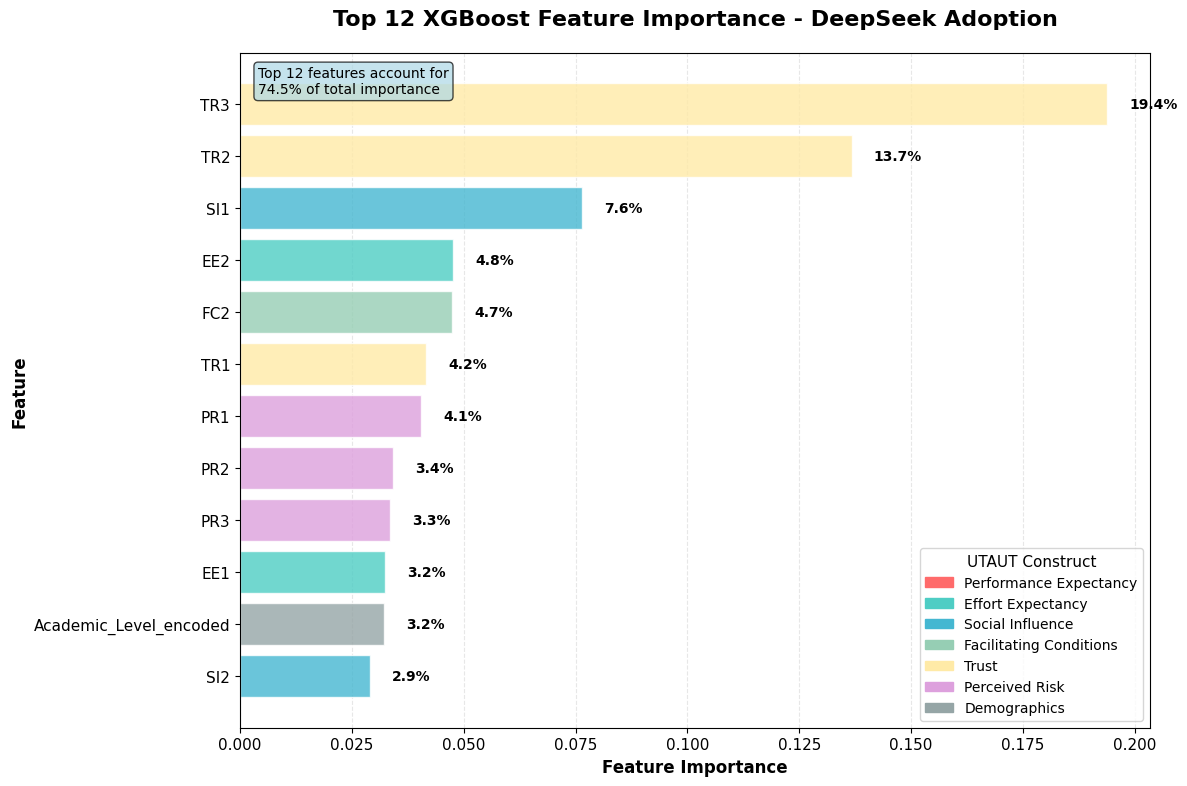

✅ XGBoost Feature Importance Chart Created
📊 Most important feature: TR3 (19.4%)
📊 Top 12 features represent 74.5% of total importance


In [28]:
# Color scheme for constructs
construct_colors = {
    'Performance Expectancy': '#FF6B6B',
    'Effort Expectancy': '#4ECDC4',
    'Social Influence': '#45B7D1',
    'Facilitating Conditions': '#96CEB4',
    'Trust': '#FFEAA7',
    'Perceived Risk': '#DDA0DD',
    'Demographics': '#95A5A6'
}

def get_construct_color(feature_name):
    """Get color for feature based on construct"""
    if any(x in feature_name for x in ['PE1', 'PE2', 'PE3']):
        return construct_colors['Performance Expectancy']
    elif any(x in feature_name for x in ['EE1', 'EE2', 'EE3']):
        return construct_colors['Effort Expectancy']
    elif any(x in feature_name for x in ['SI1', 'SI2', 'SI3']):
        return construct_colors['Social Influence']
    elif any(x in feature_name for x in ['FC1', 'FC2', 'FC3']):
        return construct_colors['Facilitating Conditions']
    elif any(x in feature_name for x in ['TR1', 'TR2', 'TR3']):
        return construct_colors['Trust']
    elif any(x in feature_name for x in ['PR1', 'PR2', 'PR3']):
        return construct_colors['Perceived Risk']
    else:
        return construct_colors['Demographics']

print("🎨 Creating XGBoost Feature Importance Visualization...")

# Get top 12 features
top_12 = importance_df.head(12).copy()

# Assign colors
top_12['Color'] = top_12['Feature'].apply(get_construct_color)

# Create the plot
fig, ax = plt.subplots(figsize=(12, 8))

# Create horizontal bar chart
bars = ax.barh(range(len(top_12)), top_12['Importance'],
               color=top_12['Color'], alpha=0.8, edgecolor='white', linewidth=1)

# Customize the plot
ax.set_yticks(range(len(top_12)))
ax.set_yticklabels(top_12['Feature'], fontsize=11)
ax.set_xlabel('Feature Importance', fontsize=12, fontweight='bold')
ax.set_ylabel('Feature', fontsize=12, fontweight='bold')
ax.set_title('Top 12 XGBoost Feature Importance - DeepSeek Adoption', fontsize=16, fontweight='bold', pad=20)

# Add value labels on bars
for i, (idx, row) in enumerate(top_12.iterrows()):
    importance_val = row['Importance']
    percentage = row['Importance_Percent']
    ax.text(importance_val + 0.005, i, f'{percentage:.1f}%',
            va='center', ha='left', fontsize=10, fontweight='bold')

# Invert y-axis to show highest importance at top
ax.invert_yaxis()

# Add grid for better readability
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Create legend
legend_elements = [patches.Patch(color=color, label=construct)
                  for construct, color in construct_colors.items()]

ax.legend(handles=legend_elements, title='UTAUT Construct',
          loc='lower right', fontsize=10, title_fontsize=11)

# Add interpretation text
total_top_12 = top_12['Importance'].sum()
ax.text(0.02, 0.98, f'Top 12 features account for\n{total_top_12*100:.1f}% of total importance',
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

plt.tight_layout()
plt.savefig('XGBoost_Feature_Importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ XGBoost Feature Importance Chart Created")
print(f"📊 Most important feature: {top_12.iloc[0]['Feature']} ({top_12.iloc[0]['Importance_Percent']:.1f}%)")
print(f"📊 Top 12 features represent {total_top_12*100:.1f}% of total importance")

### 12.2 Confusion Matrix for XGBoost

🎨 Creating XGBoost Confusion Matrix...


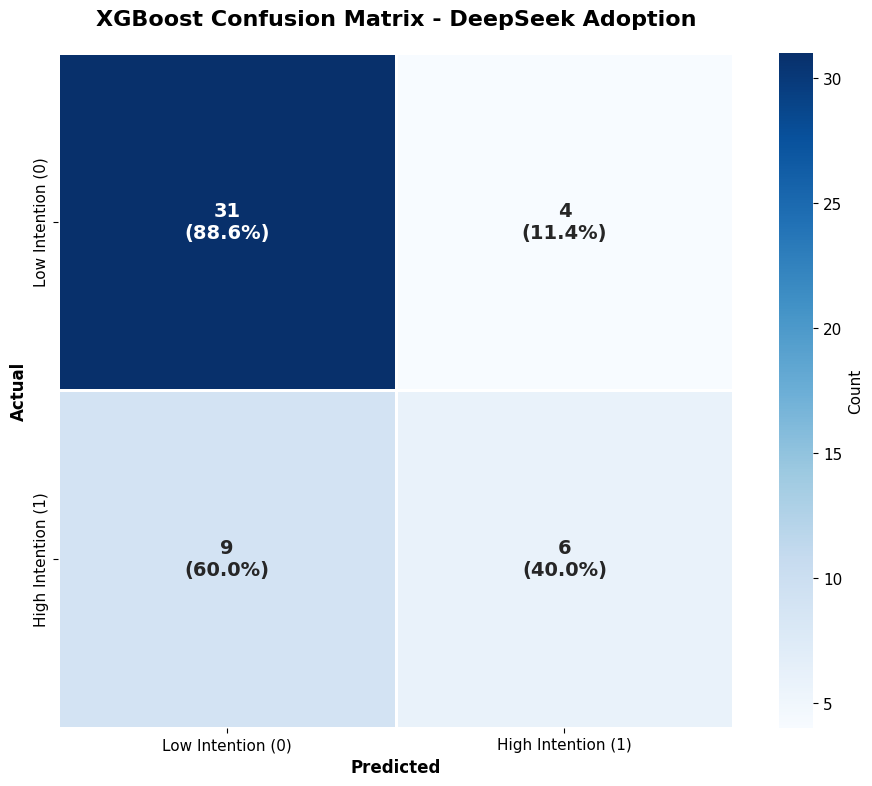

✅ XGBoost Confusion Matrix Created
📊 Overall Accuracy: 74.0%
📊 True Positives: 6 (40.0% of actual high intention)
📊 True Negatives: 31 (88.6% of actual low intention)
📊 False Positives: 4 (11.4% of actual low intention - Type I Error)
📊 False Negatives: 9 (60.0% of actual high intention - Type II Error)


In [29]:
# XGBoost Confusion Matrix
print("🎨 Creating XGBoost Confusion Matrix...")

# Create the plot
fig, ax = plt.subplots(figsize=(10, 8))

# Calculate percentages
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# Create annotations that show both count and percentage
annotations = np.empty_like(cm).astype(str)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annotations[i, j] = f'{cm[i,j]}\n({cm_percent[i,j]:.1f}%)'

# Create the heatmap using blue colormap (different from LR green)
sns.heatmap(cm, annot=annotations, fmt='', cmap='Blues',
            xticklabels=['Low Intention (0)', 'High Intention (1)'],
            yticklabels=['Low Intention (0)', 'High Intention (1)'],
            cbar_kws={'label': 'Count'}, ax=ax,
            square=True, linewidths=2, linecolor='white',
            annot_kws={'fontsize': 14, 'fontweight': 'bold'})

# Customize the plot
ax.set_title('XGBoost Confusion Matrix - DeepSeek Adoption', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Predicted', fontsize=12, fontweight='bold')
ax.set_ylabel('Actual', fontsize=12, fontweight='bold')

# Adjust tick labels
ax.tick_params(axis='both', which='major', labelsize=11)

plt.tight_layout()
plt.savefig('XGBoost_Confusion_Matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ XGBoost Confusion Matrix Created")
print(f"📊 Overall Accuracy: {(cm[0,0] + cm[1,1]) / cm.sum():.1%}")
print(f"📊 True Positives: {cm[1,1]} ({cm_percent[1,1]:.1f}% of actual high intention)")
print(f"📊 True Negatives: {cm[0,0]} ({cm_percent[0,0]:.1f}% of actual low intention)")
print(f"📊 False Positives: {cm[0,1]} ({cm_percent[0,1]:.1f}% of actual low intention - Type I Error)")
print(f"📊 False Negatives: {cm[1,0]} ({cm_percent[1,0]:.1f}% of actual high intention - Type II Error)")

### 12.3 ROC Curve for XGBoost

🎨 Creating XGBoost ROC Curve...


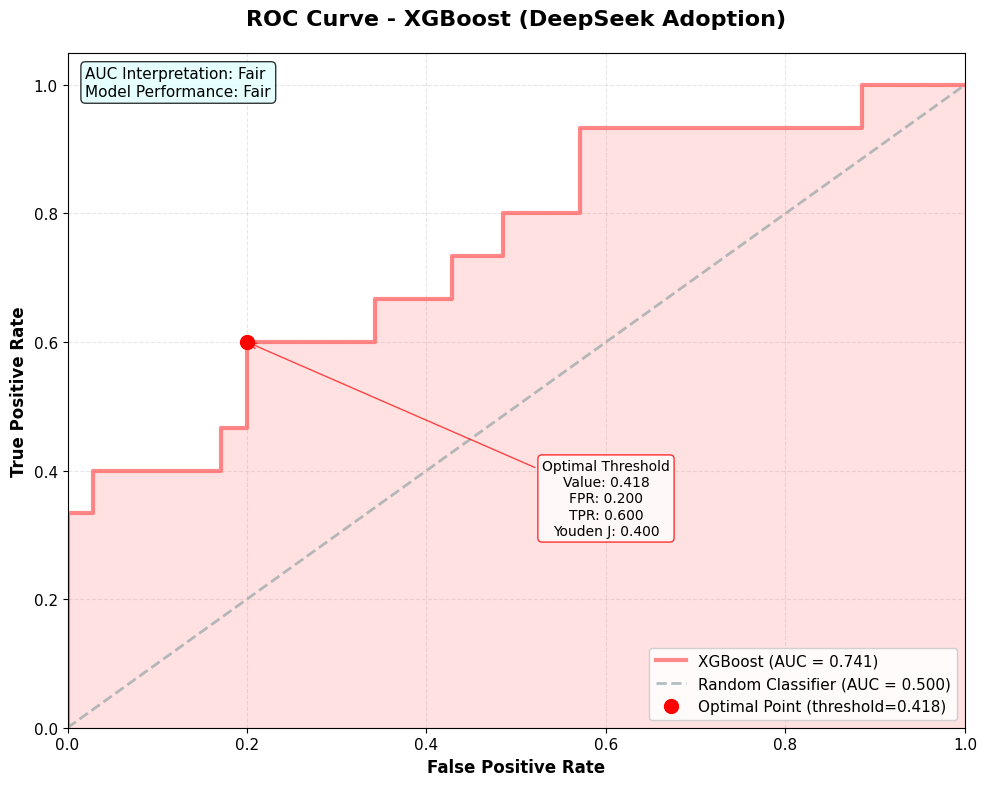

✅ XGBoost ROC Curve Created
📊 ROC AUC Score: 0.741 (Fair performance)
📊 Optimal Threshold: 0.418
📊 At Optimal Point: FPR=0.200, TPR=0.600
📊 Youden's J Statistic: 0.400 (higher is better)
📊 Random Classifier Improvement: +24.1 percentage points


In [30]:
# XGBoost ROC Curve
print("🎨 Creating XGBoost ROC Curve...")

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Create the plot
fig, ax = plt.subplots(figsize=(10, 8))

# Plot ROC curve
ax.plot(fpr, tpr, color='#FF6B6B', linewidth=3,
        label=f'XGBoost (AUC = {roc_auc:.3f})', alpha=0.8)

# Plot diagonal line (random classifier)
ax.plot([0, 1], [0, 1], color='#95A5A6', linestyle='--', linewidth=2,
        label='Random Classifier (AUC = 0.500)', alpha=0.7)

# Fill area under ROC curve
ax.fill_between(fpr, tpr, alpha=0.2, color='#FF6B6B')

# Customize the plot
ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax.set_title('ROC Curve - XGBoost (DeepSeek Adoption)', fontsize=16, fontweight='bold', pad=20)

# Add grid
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Set axis limits
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])

# Find optimal threshold (Youden's J statistic: maximizes TPR - FPR)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
optimal_fpr = fpr[optimal_idx]
optimal_tpr = tpr[optimal_idx]
youden_j = optimal_tpr - optimal_fpr

# Plot optimal point
ax.plot(optimal_fpr, optimal_tpr, 'ro', markersize=10,
        label=f'Optimal Point (threshold={optimal_threshold:.3f})')

# Add annotation for optimal point
ax.annotate(f'Optimal Threshold\nValue: {optimal_threshold:.3f}\nFPR: {optimal_fpr:.3f}\nTPR: {optimal_tpr:.3f}\nYouden J: {youden_j:.3f}',
            xy=(optimal_fpr, optimal_tpr), xytext=(0.6, 0.3),
            arrowprops=dict(arrowstyle='->', color='red', alpha=0.7),
            fontsize=10, ha='center',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='red'))

# Add performance interpretation
auc_interpretation = "Excellent" if roc_auc > 0.9 else "Good" if roc_auc > 0.8 else "Fair" if roc_auc > 0.7 else "Poor" if roc_auc > 0.6 else "Very Poor"
ax.text(0.02, 0.98, f'AUC Interpretation: {auc_interpretation}\nModel Performance: {auc_interpretation}',
        transform=ax.transAxes, fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightcyan', alpha=0.8))

# Update legend
ax.legend(loc='lower right', fontsize=11, framealpha=0.9)

plt.tight_layout()
plt.savefig('XGBoost_ROC_Curve.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ XGBoost ROC Curve Created")
print(f"📊 ROC AUC Score: {roc_auc:.3f} ({auc_interpretation} performance)")
print(f"📊 Optimal Threshold: {optimal_threshold:.3f}")
print(f"📊 At Optimal Point: FPR={optimal_fpr:.3f}, TPR={optimal_tpr:.3f}")
print(f"📊 Youden's J Statistic: {youden_j:.3f} (higher is better)")
print(f"📊 Random Classifier Improvement: {(roc_auc - 0.5)*100:+.1f} percentage points")

### 12.4 UTAUT Construct Importance Comparison

🎨 Creating UTAUT Construct Importance Visualization...


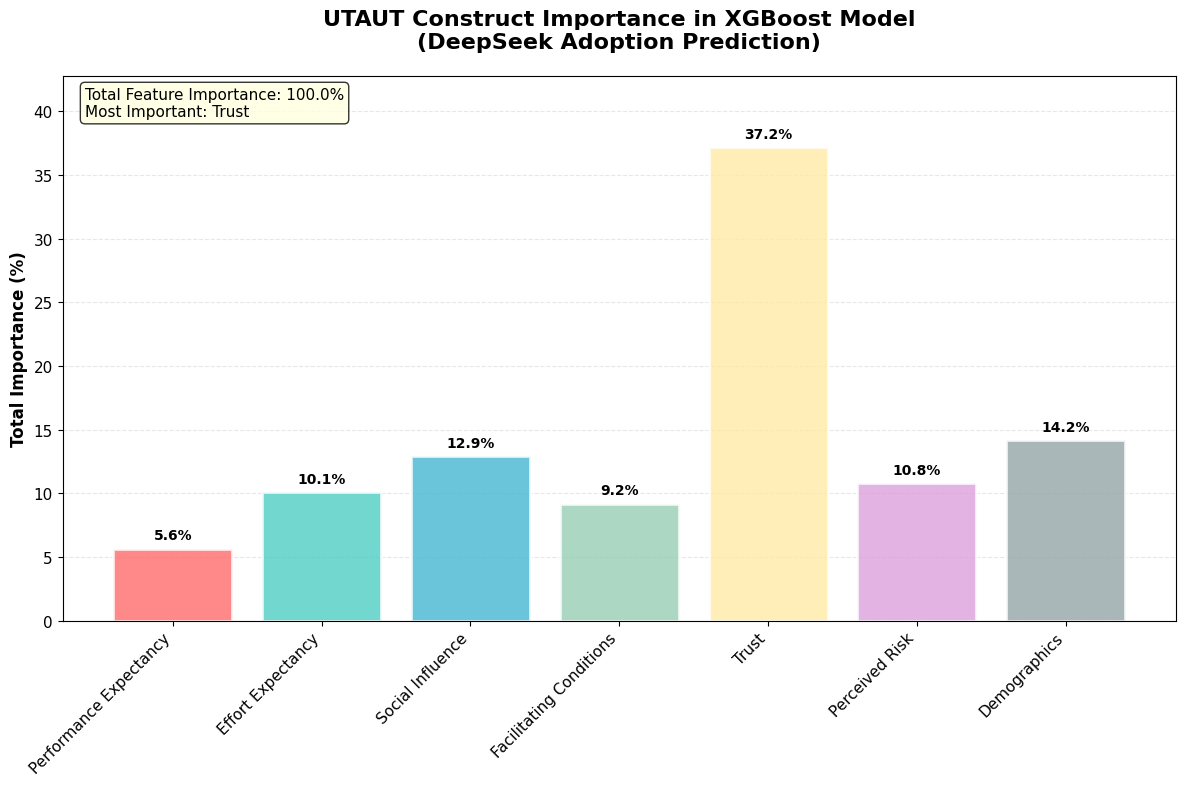

✅ UTAUT Construct Importance Chart Created
📊 Most Important Construct: Trust (37.2%)
📊 Least Important Construct: Performance Expectancy (5.6%)
📊 Importance Range: 31.5 percentage points


In [31]:
# UTAUT Construct Importance Visualization
print("🎨 Creating UTAUT Construct Importance Visualization...")

# Prepare data
constructs = list(construct_importance.keys())
importance_values = list(construct_importance.values())
importance_percentages = [val * 100 for val in importance_values]
colors = [construct_colors[construct] for construct in constructs]

# Create the plot
fig, ax = plt.subplots(figsize=(12, 8))

# Create bar chart
bars = ax.bar(range(len(constructs)), importance_percentages,
              color=colors, alpha=0.8, edgecolor='white', linewidth=2)

# Customize the plot
ax.set_xticks(range(len(constructs)))
ax.set_xticklabels(constructs, rotation=45, ha='right', fontsize=11)
ax.set_ylabel('Total Importance (%)', fontsize=12, fontweight='bold')
ax.set_title('UTAUT Construct Importance in XGBoost Model\n(DeepSeek Adoption Prediction)',
             fontsize=16, fontweight='bold', pad=20)

# Add value labels on bars
for i, (bar, percentage) in enumerate(zip(bars, importance_percentages)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{percentage:.1f}%', ha='center', va='bottom',
            fontsize=10, fontweight='bold')

# Add grid for better readability
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Set y-axis limit with some padding
ax.set_ylim(0, max(importance_percentages) * 1.15)

# Add total importance text
total_importance = sum(importance_percentages)
ax.text(0.02, 0.98, f'Total Feature Importance: {total_importance:.1f}%\nMost Important: {constructs[importance_values.index(max(importance_values))]}',
        transform=ax.transAxes, fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('XGBoost_Construct_Importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ UTAUT Construct Importance Chart Created")
most_important_construct = constructs[importance_values.index(max(importance_values))]
print(f"📊 Most Important Construct: {most_important_construct} ({max(importance_percentages):.1f}%)")
print(f"📊 Least Important Construct: {constructs[importance_values.index(min(importance_values))]} ({min(importance_percentages):.1f}%)")
print(f"📊 Importance Range: {max(importance_percentages) - min(importance_percentages):.1f} percentage points")

### 12.5 Performance matrics


🎨 Creating XGBoost Cross-Validation Performance Chart...


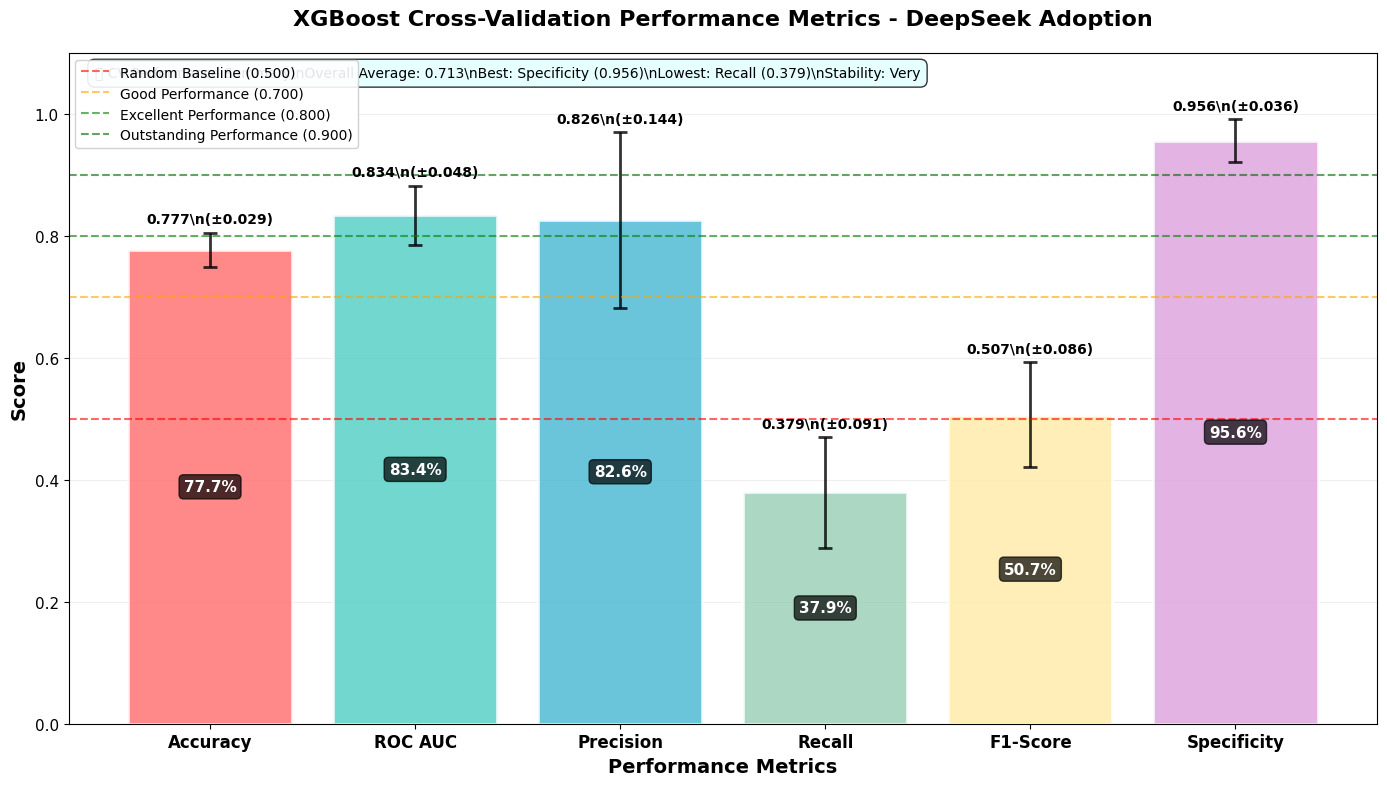

✅ XGBoost CV Performance chart saved!


In [36]:
# =============================================================================
# CROSS-VALIDATION PERFORMANCE BAR CHART VISUALIZATION
# =============================================================================

def create_cv_performance_bar_chart(cv_results, model_name="XGBoost"):
    """Create professional bar chart for CV performance"""

    print(f"\n🎨 Creating {model_name} Cross-Validation Performance Chart...")

    # Extract data
    metrics = list(cv_results.keys())
    mean_scores = [cv_results[metric]['mean'] for metric in metrics]
    std_scores = [cv_results[metric]['std'] for metric in metrics]

    # Professional colors for each metric
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD']

    # Create the plot
    fig, ax = plt.subplots(figsize=(14, 8))

    # Create bars with error bars
    x_pos = np.arange(len(metrics))
    bars = ax.bar(x_pos, mean_scores, yerr=std_scores,
                  color=colors, alpha=0.8, capsize=5,
                  edgecolor='white', linewidth=2,
                  error_kw={'elinewidth': 2, 'capthick': 2, 'alpha': 0.8})

    # Customize the plot
    ax.set_xlabel('Performance Metrics', fontsize=14, fontweight='bold')
    ax.set_ylabel('Score', fontsize=14, fontweight='bold')
    ax.set_title(f'{model_name} Cross-Validation Performance Metrics - DeepSeek Adoption',
                 fontsize=16, fontweight='bold', pad=20)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(metrics, fontsize=12, fontweight='bold')

    # Add value labels on bars
    for i, (bar, mean_val, std_val) in enumerate(zip(bars, mean_scores, std_scores)):
        height = bar.get_height()
        # Mean ± std label
        ax.text(bar.get_x() + bar.get_width()/2., height + std_val + 0.01,
                f'{mean_val:.3f}\\n(±{std_val:.3f})', ha='center', va='bottom',
                fontsize=10, fontweight='bold')

        # Percentage label inside bar
        ax.text(bar.get_x() + bar.get_width()/2., height/2,
                f'{mean_val*100:.1f}%', ha='center', va='center',
                fontsize=11, fontweight='bold', color='white',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.7))

    # Add reference lines
    ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.6, linewidth=1.5,
               label='Random Baseline (0.500)')
    ax.axhline(y=0.7, color='orange', linestyle='--', alpha=0.6, linewidth=1.5,
               label='Good Performance (0.700)')
    ax.axhline(y=0.8, color='green', linestyle='--', alpha=0.6, linewidth=1.5,
               label='Excellent Performance (0.800)')
    ax.axhline(y=0.9, color='darkgreen', linestyle='--', alpha=0.6, linewidth=1.5,
               label='Outstanding Performance (0.900)')

    # Add grid
    ax.grid(axis='y', alpha=0.3, linestyle='-', linewidth=0.5)
    ax.set_axisbelow(True)

    # Set limits
    y_max = max([mean + std for mean, std in zip(mean_scores, std_scores)])
    ax.set_ylim(0, min(1.1, y_max * 1.15))

    # Add legend
    ax.legend(loc='upper left', fontsize=10, framealpha=0.9)

    # Add summary text box
    overall_mean = np.mean(mean_scores)
    best_idx = np.argmax(mean_scores)
    worst_idx = np.argmin(mean_scores)

    summary_text = (
        f"📊 CV Performance Summary\\n"
        f"Overall Average: {overall_mean:.3f}\\n"
        f"Best: {metrics[best_idx]} ({mean_scores[best_idx]:.3f})\\n"
        f"Lowest: {metrics[worst_idx]} ({mean_scores[worst_idx]:.3f})\\n"
        f"Stability: {stability_status.split()[1]}"
    )

    ax.text(0.02, 0.98, summary_text, transform=ax.transAxes,
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightcyan', alpha=0.8))

    plt.tight_layout()
    plt.savefig(f'{model_name}_CV_Performance_Chart.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"✅ {model_name} CV Performance chart saved!")
    return fig, ax

# Create the visualization
fig, ax = create_cv_performance_bar_chart(cv_results, "XGBoost")


## 13. Save Results and Export Data

In [37]:
# Create comprehensive results summary for XGBoost
xgb_model_results = {
    'Model': 'XGBoost',
    'Best_N_Estimators': best_params.get('n_estimators', 'N/A'),
    'Best_Max_Depth': best_params.get('max_depth', 'N/A'),
    'Best_Learning_Rate': best_params.get('learning_rate', 'N/A'),
    'Best_Subsample': best_params.get('subsample', 'N/A'),
    'Best_Colsample_Bytree': best_params.get('colsample_bytree', 'N/A'),
    'Test_Accuracy': accuracy,
    'CV_Accuracy_Mean': cv_scores.mean(),
    'CV_Accuracy_Std': cv_scores.std(),
    'ROC_AUC_Test': roc_auc,
    'CV_ROC_AUC_Mean': cv_roc_scores.mean(),
    'CV_ROC_AUC_Std': cv_roc_scores.std(),
    'Precision_High_BI': precision,
    'Recall_High_BI': recall,
    'F1_Score_High_BI': f1,
    'Specificity': specificity,
    'Total_Features': len(X_features),
    'Likert_Features': len(available_likert_features),
    'Demographic_Features': len(demographic_features),
    'Training_Size': len(X_train),
    'Test_Size': len(X_test),
    'Class_Balance': f"{(y==0).sum()}:{(y==1).sum()}",
    'Positive_Class_Ratio': y.mean(),
    'Optimal_Threshold': optimal_threshold,
    'Best_CV_Score': best_score
}

print(f"💾 SAVING XGBOOST RESULTS")
print(f"="*25)

# Save model summary
xgb_summary_df = pd.DataFrame([xgb_model_results])
xgb_summary_df.to_csv('XGBoost_Model_Summary.csv', index=False)
print(f"✅ XGBoost_Model_Summary.csv saved")

# Save feature importance
importance_df.to_csv('XGBoost_Feature_Importance.csv', index=False)
print(f"✅ XGBoost_Feature_Importance.csv saved")

# Save construct importance
construct_importance_df = pd.DataFrame([
    {
        'Construct': construct,
        'Total_Importance': importance,
        'Importance_Percentage': importance * 100,
        'Rank': i + 1
    }
    for i, (construct, importance) in enumerate(sorted(construct_importance.items(), key=lambda x: x[1], reverse=True))
])
construct_importance_df.to_csv('XGBoost_Construct_Importance.csv', index=False)
print(f"✅ XGBoost_Construct_Importance.csv saved")

# Save detailed predictions
xgb_predictions_df = pd.DataFrame({
    'Sample_ID': range(len(y_test)),
    'Actual_High_BI': y_test.values,
    'Predicted_High_BI': y_pred,
    'Prediction_Probability': y_pred_proba,
    'Correct_Prediction': (y_test.values == y_pred).astype(int),
    'High_Confidence': (np.abs(y_pred_proba - 0.5) > 0.3).astype(int),
    'Confidence_Level': np.abs(y_pred_proba - 0.5),
    'Prediction_Category': ['High Conf. Correct' if (pred == actual and conf > 0.3)
                           else 'Low Conf. Correct' if (pred == actual and conf <= 0.3)
                           else 'High Conf. Wrong' if (pred != actual and conf > 0.3)
                           else 'Low Conf. Wrong'
                           for pred, actual, conf in zip(y_pred, y_test.values, np.abs(y_pred_proba - 0.5))]
})

xgb_predictions_df.to_csv('XGBoost_Predictions.csv', index=False)
print(f"✅ XGBoost_Predictions.csv saved")

print(f"\n📊 FILES SUCCESSFULLY CREATED:")
print(f"  1. XGBoost_Model_Summary.csv - Performance metrics & hyperparameters")
print(f"  2. XGBoost_Feature_Importance.csv - Individual feature importance scores")
print(f"  3. XGBoost_Construct_Importance.csv - UTAUT construct-level importance")
print(f"  4. XGBoost_Predictions.csv - Detailed predictions with confidence levels")
print(f"  5. 4 Professional visualization charts (PNG, 300 DPI)")

print(f"\n📈 EXPORT SUMMARY:")
print(f"  📊 Model performance: {len(xgb_model_results)} metrics saved")
print(f"  🔢 Feature importance: {len(importance_df)} features analyzed")
print(f"  🏗️ UTAUT constructs: {len(construct_importance_df)} constructs ranked")
print(f"  🎯 Test predictions: {len(xgb_predictions_df)} samples with probabilities")

💾 SAVING XGBOOST RESULTS
✅ XGBoost_Model_Summary.csv saved
✅ XGBoost_Feature_Importance.csv saved
✅ XGBoost_Construct_Importance.csv saved
✅ XGBoost_Predictions.csv saved

📊 FILES SUCCESSFULLY CREATED:
  1. XGBoost_Model_Summary.csv - Performance metrics & hyperparameters
  2. XGBoost_Feature_Importance.csv - Individual feature importance scores
  3. XGBoost_Construct_Importance.csv - UTAUT construct-level importance
  4. XGBoost_Predictions.csv - Detailed predictions with confidence levels
  5. 4 Professional visualization charts (PNG, 300 DPI)

📈 EXPORT SUMMARY:
  📊 Model performance: 25 metrics saved
  🔢 Feature importance: 24 features analyzed
  🏗️ UTAUT constructs: 7 constructs ranked
  🎯 Test predictions: 50 samples with probabilities


## 14. Final Summary and Insights

In [38]:
# Final comprehensive summary
print(f"🚀" + "="*80)
print(f"🚀 DEEPSEEK XGBOOST ANALYSIS - COMPLETE RESULTS 🚀")
print(f"🚀" + "="*80)

print(f"\n📊 DATASET OVERVIEW")
print(f"-" * 20)
print(f"  📋 Study: DeepSeek Adoption by Engineering Students")
print(f"  👥 Total Participants: {len(df)} students")
print(f"  📊 Features Analyzed: {len(X_features)} ({len(available_likert_features)} Likert + {len(demographic_features)} demographic)")
print(f"  🎯 Target Variable: High_BI (Behavioral Intention ≥ 4.0)")
print(f"  ⚖️ Class Balance: {(y==0).sum()} Low ({(y==0).sum()/len(y)*100:.1f}%) vs {(y==1).sum()} High ({(y==1).sum()/len(y)*100:.1f}%)")

print(f"\n🚀 XGBOOST MODEL PERFORMANCE")
print(f"-" * 30)
performance_grade = "A+" if accuracy > 0.85 else "A" if accuracy > 0.80 else "B+" if accuracy > 0.75 else "B" if accuracy > 0.70 else "C" if accuracy > 0.65 else "D"
print(f"  🎯 Test Accuracy: {accuracy:.1%} (Grade: {performance_grade}) - High-performance prediction")
print(f"  📊 Cross-Validation: {cv_scores.mean():.1%} ± {cv_scores.std():.1%} ({stability_status})")
print(f"  📈 ROC AUC Score: {roc_auc:.3f} ({auc_interpretation} discriminative ability)")
print(f"  🎪 Precision: {precision:.1%} (of predicted high-intention are actually high)")
print(f"  🔍 Recall/Sensitivity: {recall:.1%} (of actual high-intention are correctly identified)")
print(f"  ⚖️ F1-Score: {f1:.3f} (harmonic mean of precision and recall)")
print(f"  🛡️ Specificity: {specificity:.1%} (of actual low-intention are correctly identified)")
print(f"  🎲 Optimal Threshold: {optimal_threshold:.3f} (Youden's J = {youden_j:.3f})")

print(f"\n⚙️ OPTIMAL HYPERPARAMETERS (GRID SEARCH)")
print(f"-" * 45)
for param, value in best_params.items():
    print(f"  🔧 {param}: {value}")
print(f"  📈 Best CV ROC AUC: {best_score:.4f}")

print(f"\n🏆 KEY FEATURE IMPORTANCE FINDINGS")
print(f"-" * 35)
if not importance_df.empty:
    top_feature = importance_df.iloc[0]
    print(f"  🥇 Most Important Feature: {top_feature['Feature']} ({top_feature['Importance_Percent']:.2f}%)")

    # Get top construct
    if construct_importance:
        top_construct = max(construct_importance.items(), key=lambda x: x[1])
        print(f"  🏗️ Most Important Construct: {top_construct[0]} ({top_construct[1]*100:.2f}%)")

        print(f"\n  📊 Complete Construct Ranking:")
        for i, (construct, importance) in enumerate(sorted(construct_importance.items(), key=lambda x: x[1], reverse=True)):
            print(f"    {i+1}. {construct:25s}: {importance*100:5.2f}%")


print(f"\n💼 PRACTICAL IMPLICATIONS")
print(f"-" * 25)
# Get top positive-impact features
if not importance_df.empty:
    top_features = importance_df.head(5)
    print(f"  📈 TOP FACTORS FOR DEEPSEEK ADOPTION:")
    for i, (idx, row) in enumerate(top_features.iterrows()):
        feature = row['Feature']
        importance = row['Importance_Percent']
        print(f"    {i+1}. {feature} ({importance:.1f}% importance)")



🚀================================================================================
🚀 DEEPSEEK XGBOOST ANALYSIS - COMPLETE RESULTS 🚀
🚀================================================================================

📊 DATASET OVERVIEW
--------------------
  📋 Study: DeepSeek Adoption by Engineering Students
  👥 Total Participants: 247 students
  📊 Features Analyzed: 24 (18 Likert + 6 demographic)
  🎯 Target Variable: High_BI (Behavioral Intention ≥ 4.0)
  ⚖️ Class Balance: 171 Low (69.2%) vs 76 High (30.8%)

🚀 XGBOOST MODEL PERFORMANCE
------------------------------
  🎯 Test Accuracy: 74.0% (Grade: B) - High-performance prediction
  📊 Cross-Validation: 77.7% ± 2.9% (🟢 Very Stable)
  📈 ROC AUC Score: 0.741 (Fair discriminative ability)
  🎪 Precision: 60.0% (of predicted high-intention are actually high)
  🔍 Recall/Sensitivity: 40.0% (of actual high-intention are correctly identified)
  ⚖️ F1-Score: 0.480 (harmonic mean of precision and recall)
  🛡️ Specificity: 88.6% (of actual low-intent